# Importing Libraries

In [39]:
!pip install -q transformers datasets accelerate evaluate scikit-learn optuna

In [40]:
import numpy as np
import pandas as pd
import torch
import random
import optuna
import evaluate

from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    set_seed
)
from datasets import Dataset
from tqdm.auto import tqdm
from transformers.utils.logging import disable_progress_bar
disable_progress_bar()
from datasets.utils.logging import disable_progress_bar
disable_progress_bar()
from transformers import logging
logging.set_verbosity_error()
evaluate.logging.disable_progress_bar()
import warnings
warnings.filterwarnings("ignore")

In [41]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# Importing datasets

In [42]:
! gdown 1o_E9XCDt0iMkcJhvwQbRrVpfo3FAi2nq
! gdown 1U_NPI_FyBOMSNtcJEBNONDeYoOLMNIrY
! gdown 11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw

Downloading...
From: https://drive.google.com/uc?id=1o_E9XCDt0iMkcJhvwQbRrVpfo3FAi2nq
To: /content/jigsaw_bert_dataset.csv
100% 20.9M/20.9M [00:00<00:00, 128MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1U_NPI_FyBOMSNtcJEBNONDeYoOLMNIrY
To: /content/twitter_bert_dataset.csv
100% 1.15M/1.15M [00:00<00:00, 169MB/s]
Downloading...
From: https://drive.google.com/uc?id=11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw
To: /content/combined_model_dataset.csv
100% 22.0M/22.0M [00:00<00:00, 174MB/s]


In [43]:
df_google = pd.read_csv('/content/jigsaw_bert_dataset.csv')
df_twitter = pd.read_csv('/content/twitter_bert_dataset.csv')
df_combined = pd.read_csv('/content/combined_model_dataset.csv')


# Data preperation

## Text preprocessing

In [44]:
!pip install contractions

In [45]:
import re
import nltk
import contractions
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))- {"not", "no"}

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [46]:
def preprocess_bert(text):
  if not text or str(text).strip() == "":
    return ""
  # lowercase
  text = text.lower()

  # remove mentions
  text = re.sub(r'@\w+', 'user', text)

  # remove hashtag symbol but keep word
  text = re.sub(r'#', '', text)

  # remove URLs
  text = re.sub(r'http\S+|www\S+', '', text)

  # remove black bars
  text = re.sub(r'█+', ' ', text)

  # remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

In [47]:
df_google["text"] = df_google["text"].apply(preprocess_bert)
df_google

,text,label
0,"was the girl on any prescription drugs? if so,...",0
1,"while the tax will have an effect, the real ef...",0
2,what makes you think i believe the posts in qu...,0
3,and so canada devolves into nonfunctional irre...,0
4,"boomer 88, a rather defeatist attitude and lam...",0
...,...,...
69995,and another childish insult from clearly an em...,1
69996,"no, you just call them deviants and perverts.",1
69997,"well said, bumpkin. i'm more inclined to liste...",1
69998,did i mention that mars is undergoing climate ...,1


In [48]:
df_twitter["text"] = df_twitter["text"].apply(preprocess_bert)
df_twitter

,text,label
0,user nice new signage. are you not concerned b...,0
1,a woman who you fucked multiple times saying y...,1
2,user user real talk do you have eyes or were t...,1
3,your girlfriend lookin at me like a groupie in...,1
4,hysterical woman like user,0
...,...,...
8949,oooohhhh bitch didn't even listen to the dead ...,0
8950,user good luck user more americans walkawayfro...,0
8951,bitch you can't keep up so stop trying,1
8952,user user user user user user japan is always ...,0


In [49]:
df_combined["text"] = df_combined["text"].apply(preprocess_bert)
df_combined

,text,label
0,"this is politicians' strategy ""action through ...",0
1,he has underlings to do tjat for him,0
2,"judge on separation of immigrant families: ""if...",0
3,to the republican nra(nazi's razing america)th...,0
4,somebody musta complained.,0
...,...,...
78949,throw a little pesticide on top of carcinogen ...,0
78950,this man is a coward & an oath breaker & the w...,1
78951,a propublica investigation found that police r...,0
78952,you answered the question better than i could ...,0


## Spliting dataset into train and test

In [50]:
X = df_combined['text']
y = df_combined['label']

In [51]:
X_tr, X_test, y_tr, y_test = train_test_split(X,y,test_size = 0.20, random_state = 42, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_tr,y_tr,test_size = 0.25, random_state = 42, stratify = y_tr)

In [52]:
X_train.shape

(47372,)

In [53]:
X_test.shape

(15791,)

In [54]:
train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True)
})

val_df = pd.DataFrame({
    "text": X_val.reset_index(drop=True),
    "label": y_val.reset_index(drop=True)
})

test_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test.reset_index(drop=True)
})

In [55]:
train_df

,text,label
0,what a jack***!,1
1,the insane re truly in charge... the german go...,1
2,"roy, i notice you always ""like"" your own comme...",0
3,senator lisa has given exemplary service to th...,0
4,while it certainly makes sense to get more val...,0
...,...,...
47367,user user user women are all harassed? and it'...,1
47368,lots of trump supporters voted for him because...,1
47369,it's this stupid system they've brought in. a ...,1
47370,"the headline is indeed wrong, but it should re...",0


In [56]:
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

(47372, 2) (15791, 2) (15791, 2)
label
0    24106
1    23266
Name: count, dtype: int64
label
0    8035
1    7756
Name: count, dtype: int64
label
0    8036
1    7755
Name: count, dtype: int64


##  Converting to Hugging Face datasets

In [57]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

## Tokenization

In [58]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [59]:
MAX_LENGTH = 128
def tokenize_batch(batch):
  return tokenizer(
      batch['text'],
      truncation = True,
      max_length = MAX_LENGTH
  )

In [60]:
train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)
test_tok  = test_ds.map(tokenize_batch, batched=True)

In [61]:
test_tok

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 15791
})

## Set dataset format

In [62]:
cols = ["input_ids", "attention_mask", "label"]

train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

# Evaluation metrics

In [63]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    prec = precision_metric.compute(predictions=preds, references=labels, average="binary")["precision"]
    rec = recall_metric.compute(predictions=preds, references=labels, average="binary")["recall"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"]

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

# Hyperparameter tuning

In [64]:
def build_model():
  return AutoModelForSequenceClassification.from_pretrained(
      MODEL_NAME,
      num_labels = 2
  )
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

In [65]:
def objective(trial):
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
  batch_size = trial.suggest_categorical("batch_size",[8,16])
  num_train_epochs = trial.suggest_int("num_train_epochs",1,2)
  weight_decay = trial.suggest_float("weight_decay", 0.0, 1.0)
  model = build_model()
  args = TrainingArguments(
      output_dir = f"./stage1_trial_{trial.number}",
      eval_strategy = "epoch",
      save_strategy = 'epoch',
      logging_strategy = "epoch",
      learning_rate = learning_rate,
      per_device_train_batch_size = batch_size,
      per_device_eval_batch_size = batch_size,
      weight_decay = weight_decay,
      load_best_model_at_end = True,
      metric_for_best_model = 'f1',
      greater_is_better = True,
      report_to = "none",
      disable_tqdm=True,
      seed = SEED,
      fp16=torch.cuda.is_available()
  )
  trainer = Trainer(
      model = model,
      args = args,
      train_dataset = train_tok,
      eval_dataset = val_tok,
      data_collator = data_collator,
      compute_metrics = compute_metrics,
      callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]

  )
  trainer.train()
  eval_results = trainer.evaluate()
  return eval_results["eval_f1"]

In [66]:
study = optuna.create_study(direction = "maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials = 5)
print("Best params:", study.best_params)
print("Best F1:", study.best_value)

[I 2026-04-13 20:15:48,883] A new study created in memory with name: no-name-3d0d2f49-e1ef-4819-ac0c-8b0a54da6671


{'loss': '0.3757', 'grad_norm': '34.41', 'learning_rate': '1.218e-05', 'epoch': '1'}
{'eval_loss': '0.3937', 'eval_accuracy': '0.8634', 'eval_precision': '0.8546', 'eval_recall': '0.8699', 'eval_f1': '0.8622', 'eval_runtime': '19.84', 'eval_samples_per_second': '795.9', 'eval_steps_per_second': '99.49', 'epoch': '1'}
{'loss': '0.284', 'grad_norm': '1.034', 'learning_rate': '6.092e-06', 'epoch': '2'}
{'eval_loss': '0.4335', 'eval_accuracy': '0.8618', 'eval_precision': '0.8229', 'eval_recall': '0.9157', 'eval_f1': '0.8668', 'eval_runtime': '19.77', 'eval_samples_per_second': '798.9', 'eval_steps_per_second': '99.87', 'epoch': '2'}
{'loss': '0.2055', 'grad_norm': '0.3899', 'learning_rate': '1.028e-09', 'epoch': '3'}
{'eval_loss': '0.5313', 'eval_accuracy': '0.8681', 'eval_precision': '0.854', 'eval_recall': '0.8823', 'eval_f1': '0.8679', 'eval_runtime': '19.65', 'eval_samples_per_second': '803.4', 'eval_steps_per_second': '100.4', 'epoch': '3'}
{'train_runtime': '744.4', 'train_samples_pe

[I 2026-04-13 20:28:33,923] Trial 0 finished with value: 0.867905383981229 and parameters: {'learning_rate': 1.827226177606625e-05, 'batch_size': 8, 'num_train_epochs': 2, 'weight_decay': 0.15601864044243652}. Best is trial 0 with value: 0.867905383981229.


{'eval_loss': '0.5313', 'eval_accuracy': '0.8681', 'eval_precision': '0.854', 'eval_recall': '0.8823', 'eval_f1': '0.8679', 'eval_runtime': '19.7', 'eval_samples_per_second': '801.5', 'eval_steps_per_second': '100.2', 'epoch': '3'}
{'loss': '0.3629', 'grad_norm': '7.716', 'learning_rate': '8.571e-06', 'epoch': '1'}
{'eval_loss': '0.3252', 'eval_accuracy': '0.8644', 'eval_precision': '0.8616', 'eval_recall': '0.8626', 'eval_f1': '0.8621', 'eval_runtime': '11.13', 'eval_samples_per_second': '1419', 'eval_steps_per_second': '88.7', 'epoch': '1'}
{'loss': '0.2725', 'grad_norm': '18.87', 'learning_rate': '4.286e-06', 'epoch': '2'}
{'eval_loss': '0.332', 'eval_accuracy': '0.8644', 'eval_precision': '0.837', 'eval_recall': '0.899', 'eval_f1': '0.8669', 'eval_runtime': '11.22', 'eval_samples_per_second': '1408', 'eval_steps_per_second': '87.99', 'epoch': '2'}
{'loss': '0.2156', 'grad_norm': '15.5', 'learning_rate': '1.447e-09', 'epoch': '3'}
{'eval_loss': '0.3642', 'eval_accuracy': '0.8678', '

[I 2026-04-13 20:35:28,287] Trial 1 finished with value: 0.8678313710596278 and parameters: {'learning_rate': 1.2853916978930139e-05, 'batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.7080725777960455}. Best is trial 0 with value: 0.867905383981229.


...

{'eval_loss': '0.4682', 'eval_accuracy': '0.8691', 'eval_precision': '0.8541', 'eval_recall': '0.8846', 'eval_f1': '0.8691', 'eval_runtime': '19.47', 'eval_samples_per_second': '811.2', 'eval_steps_per_second': '101.4', 'epoch': '3'}
{'loss': '0.3623', 'grad_norm': '7.848', 'learning_rate': '8.957e-06', 'epoch': '1'}
{'eval_loss': '0.3249', 'eval_accuracy': '0.8642', 'eval_precision': '0.861', 'eval_recall': '0.8628', 'eval_f1': '0.8619', 'eval_runtime': '11.02', 'eval_samples_per_second': '1433', 'eval_steps_per_second': '89.6', 'epoch': '1'}
{'loss': '0.2698', 'grad_norm': '19.55', 'learning_rate': '4.479e-06', 'epoch': '2'}
{'eval_loss': '0.3338', 'eval_accuracy': '0.8649', 'eval_precision': '0.8376', 'eval_recall': '0.8993', 'eval_f1': '0.8674', 'eval_runtime': '11.01', 'eval_samples_per_second': '1434', 'eval_steps_per_second': '89.62', 'epoch': '2'}
{'loss': '0.2105', 'grad_norm': '16.36', 'learning_rate': '1.512e-09', 'epoch': '3'}
{'eval_loss': '0.3716', 'eval_accuracy': '0.868

[I 2026-04-13 20:54:59,992] Trial 3 finished with value: 0.8678335870116692 and parameters: {'learning_rate': 1.34336568680343e-05, 'batch_size': 16, 'num_train_epochs': 1, 'weight_decay': 0.2912291401980419}. Best is trial 2 with value: 0.8690860725821775.


{'eval_loss': '0.3716', 'eval_accuracy': '0.868', 'eval_precision': '0.854', 'eval_recall': '0.8822', 'eval_f1': '0.8678', 'eval_runtime': '11.14', 'eval_samples_per_second': '1418', 'eval_steps_per_second': '88.6', 'epoch': '3'}
{'loss': '0.358', 'grad_norm': '7.101', 'learning_rate': '1.785e-05', 'epoch': '1'}
{'eval_loss': '0.3313', 'eval_accuracy': '0.8639', 'eval_precision': '0.8557', 'eval_recall': '0.8695', 'eval_f1': '0.8626', 'eval_runtime': '11.06', 'eval_samples_per_second': '1427', 'eval_steps_per_second': '89.21', 'epoch': '1'}
{'loss': '0.2485', 'grad_norm': '14.15', 'learning_rate': '8.927e-06', 'epoch': '2'}
{'eval_loss': '0.3499', 'eval_accuracy': '0.8664', 'eval_precision': '0.8345', 'eval_recall': '0.9082', 'eval_f1': '0.8698', 'eval_runtime': '11.08', 'eval_samples_per_second': '1425', 'eval_steps_per_second': '89.1', 'epoch': '2'}
{'loss': '0.1616', 'grad_norm': '17.5', 'learning_rate': '3.014e-09', 'epoch': '3'}
{'eval_loss': '0.4407', 'eval_accuracy': '0.8689', '

[I 2026-04-13 21:01:49,505] Trial 4 finished with value: 0.8698765432098765 and parameters: {'learning_rate': 2.6771137242145903e-05, 'batch_size': 16, 'num_train_epochs': 1, 'weight_decay': 0.45606998421703593}. Best is trial 4 with value: 0.8698765432098765.


{'eval_loss': '0.3499', 'eval_accuracy': '0.8665', 'eval_precision': '0.8344', 'eval_recall': '0.9085', 'eval_f1': '0.8699', 'eval_runtime': '11.16', 'eval_samples_per_second': '1415', 'eval_steps_per_second': '88.45', 'epoch': '3'}
Best params: {'learning_rate': 2.6771137242145903e-05, 'batch_size': 16, 'num_train_epochs': 1, 'weight_decay': 0.45606998421703593}
Best F1: 0.8698765432098765


# Training DistilBert model on best parameters

In [67]:
best_params = study.best_params
final_model = build_model()
final_model_args = TrainingArguments(
      output_dir = "./distilbert_google_stage1",
      eval_strategy = "epoch",
      save_strategy = 'epoch',
      logging_strategy = "epoch",
      learning_rate = best_params['learning_rate'],
      per_device_train_batch_size = best_params['batch_size'],
      per_device_eval_batch_size = best_params['batch_size'],
      weight_decay = best_params['weight_decay'],
      load_best_model_at_end = True,
      metric_for_best_model = 'f1',
      greater_is_better = True,
      report_to = "none",
      disable_tqdm=True,
      seed = SEED,
      fp16=torch.cuda.is_available()
)
final_trainer = Trainer(
      model = final_model,
      args =  final_model_args,
      train_dataset = train_tok,
      eval_dataset = val_tok,
      data_collator = data_collator,
      compute_metrics = compute_metrics,
      callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]

  )

final_trainer.train()
final_eval = final_trainer.evaluate(val_tok)
print("Model evaluation: ", final_eval)

{'loss': '0.358', 'grad_norm': '7.101', 'learning_rate': '1.785e-05', 'epoch': '1'}
{'eval_loss': '0.3313', 'eval_accuracy': '0.8639', 'eval_precision': '0.8557', 'eval_recall': '0.8695', 'eval_f1': '0.8626', 'eval_runtime': '11.06', 'eval_samples_per_second': '1428', 'eval_steps_per_second': '89.27', 'epoch': '1'}
{'loss': '0.2485', 'grad_norm': '14.15', 'learning_rate': '8.927e-06', 'epoch': '2'}
{'eval_loss': '0.3499', 'eval_accuracy': '0.8664', 'eval_precision': '0.8345', 'eval_recall': '0.9082', 'eval_f1': '0.8698', 'eval_runtime': '10.9', 'eval_samples_per_second': '1448', 'eval_steps_per_second': '90.53', 'epoch': '2'}
{'loss': '0.1616', 'grad_norm': '17.5', 'learning_rate': '3.014e-09', 'epoch': '3'}
{'eval_loss': '0.4407', 'eval_accuracy': '0.8689', 'eval_precision': '0.855', 'eval_recall': '0.8828', 'eval_f1': '0.8687', 'eval_runtime': '11.05', 'eval_samples_per_second': '1430', 'eval_steps_per_second': '89.36', 'epoch': '3'}
{'train_runtime': '396.9', 'train_samples_per_seco

# Evaluating DistlBert Model

In [68]:
test_results = final_trainer.evaluate(test_tok)
print("Test results:", test_results)

{'eval_loss': '0.3456', 'eval_accuracy': '0.8712', 'eval_precision': '0.8417', 'eval_recall': '0.9086', 'eval_f1': '0.8739', 'eval_runtime': '11.12', 'eval_samples_per_second': '1420', 'eval_steps_per_second': '88.74', 'epoch': '3'}
Test results: {'eval_loss': 0.3455982506275177, 'eval_accuracy': 0.871192451396365, 'eval_precision': 0.8417154461832517, 'eval_recall': 0.908575112830432, 'eval_f1': 0.8738682872380007, 'eval_runtime': 11.1228, 'eval_samples_per_second': 1419.695, 'eval_steps_per_second': 88.737, 'epoch': 3.0}


In [69]:
pred_output = final_trainer.predict(test_tok)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = np.array(test_df["label"])


In [70]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix
print(f'Accuracy of DistilBERT Classifier:{accuracy_score(y_true,y_pred)}')
print(f'Precision of DistilBERT Classifier:{precision_score(y_true,y_pred)}')
print(f'Recall of DistilBERT Classifier:{recall_score(y_true,y_pred)}')
print(f'F1 Score of DistilBERT Classifier:{f1_score(y_true,y_pred)}')
print(f"ROC-AUC score of DistilBERT Classifier:{roc_auc_score(y_true,y_pred)}")

Accuracy of DistilBERT Classifier:0.871192451396365
Precision of DistilBERT Classifier:0.8417154461832517
Recall of DistilBERT Classifier:0.908575112830432
F1 Score of DistilBERT Classifier:0.8738682872380007
ROC-AUC score of DistilBERT Classifier:0.871846043224574


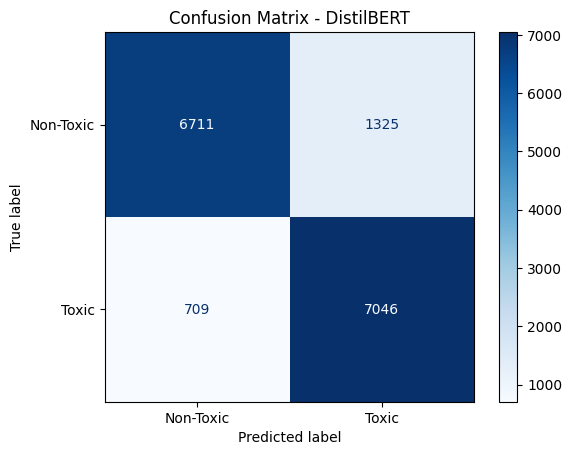

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
sns.reset_orig()
cm = confusion_matrix(y_true, y_pred)
labels = ["Non-Toxic", "Toxic"]   # adjust if your mapping is reversed
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - DistilBERT")
plt.show()

In [72]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87      8036
           1       0.84      0.91      0.87      7755

    accuracy                           0.87     15791
   macro avg       0.87      0.87      0.87     15791
weighted avg       0.87      0.87      0.87     15791



In [73]:
final_trainer.save_model("./final_distilbert_trained")
tokenizer.save_pretrained("./final_distilbert_trained")

('./final_distilbert_trained/tokenizer_config.json',
 './final_distilbert_trained/tokenizer.json')

In [74]:
pred_output = final_trainer.predict(test_tok)

logits = pred_output.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

y_prob_bert = probs[:, 1]

In [75]:
import pickle
import os

save_path = "/content/"   # or Google Drive path

with open(save_path + "y_prob_bert.pkl", "wb") as f:
    pickle.dump(y_prob_bert, f)

print(" Probability file saved!")

 Probability file saved!


In [76]:
!zip -r distilbert_model.zip ./final_distilbert_trained

  adding: final_distilbert_trained/ (stored 0%)
  adding: final_distilbert_trained/config.json (deflated 49%)
  adding: final_distilbert_trained/model.safetensors (deflated 8%)
  adding: final_distilbert_trained/tokenizer.json (deflated 71%)
  adding: final_distilbert_trained/training_args.bin (deflated 53%)
  adding: final_distilbert_trained/tokenizer_config.json (deflated 42%)


# Assessment

**Why this model was chosen**
- DistilBERT is a transformer-based model capable of capturing contextual meaning in text.
- It outperforms classical models by understanding semantics, sarcasm, and word dependencies.

**Model assumptions**
- Does not assume feature independence
- Learns contextual embeddings using self-attention
- Requires large data and computational resources

**Hyperparameter tuning**
- Used Optuna to tune:
  - learning rate (1e-5 to 5e-5)
  - batch size (8, 16)
  - number of epochs (2–4)
  - weight decay
- Also used:
  - early stopping
  - validation-based model selection

**Challenges**

$$
\begin{array}{|l|l|}
\hline
\textbf{Challenge} & \textbf{Solution} \\
\hline
\text{Why this model was chosen} &
\begin{array}{l}
\text{DistilBERT is a transformer-based model capable of capturing contextual meaning in text.} \\
\text{It outperforms classical models by understanding semantics, sarcasm, and word dependencies.}
\end{array} \\
\hline
\text{Model assumptions} &
\begin{array}{l}
\text{Does not assume feature independence} \\
\text{Learns contextual embeddings using self-attention} \\
\text{Requires large data and computational resources}
\end{array} \\
\hline
\text{Hyperparameter tuning} &
\begin{array}{l}
\text{Used Optuna to tune:} \\
\text{learning rate (1e-5 to 5e-5)} \\
\text{batch size (8, 16)} \\
\text{number of epochs (2–4)} \\
\text{weight decay} \\
\text{Also used:} \\
\text{early stopping} \\
\text{validation-based model selection}
\end{array} \\
\hline
\end{array}
$$

# Before and After Transformation Snapshot

## Before Transformation

In [77]:
! gdown 11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw

Downloading...
From: https://drive.google.com/uc?id=11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw
To: /content/combined_model_dataset.csv
100% 22.0M/22.0M [00:00<00:00, 227MB/s]


In [78]:
import pandas as pd
df_raw = pd.read_csv('/content/combined_model_dataset.csv')
df_raw[['text', 'label']].head()

,text,label
0,"this is politicians' strategy\n\n""Action throu...",0
1,He has underlings to do tjat for him,0
2,"Judge on separation of immigrant families: ""if...",0
3,To the republican nra(Nazi's Razing America)th...,0
4,Somebody musta complained.,0


In [79]:
print('\nShape:', df_raw.shape)
print('Dtype:', df_raw['text'].dtype)


Shape: (78954, 2)
Dtype: object


## After transformation Snapshot

For DistilBERT, minimal preprocessing is applied to preserve contextual information. The text is tokenized using a pretrained tokenizer, converting sentences into input IDs and attention masks. These tokenized representations are then fed into the transformer model, which learns contextual embeddings for classification.

In [86]:
sample_text = df_raw["text"].iloc[0]

encoded = tokenizer(sample_text, truncation=True)
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

token_df = pd.DataFrame({
    "token": tokens,
    "input_id": encoded["input_ids"],
    "attention_mask": encoded["attention_mask"]
})

print("Original text:")
print(sample_text)
print("\nTokenized representation:")
token_df.head(30)

Original text:
this is politicians' strategy

"Action through non-action"

Tokenized representation:


,token,input_id,attention_mask
0,[CLS],101,1
1,this,2023,1
2,is,2003,1
3,politicians,8801,1
4,',1005,1
5,strategy,5656,1
6,"""",1000,1
7,action,2895,1
8,through,2083,1
9,non,2512,1


## Transformation Summary

In [84]:
import pandas as pd

summary = {
    "Stage": ["BEFORE", "STEP", "AFTER"],
    "Description": [
        "Raw Text",
        "After Preprocessing (lowercasing, URL removal, tokenization)",
        "After DistilBERT Tokenizer (HuggingFace)"
    ],
    "Format": [
        "String",
        "Cleaned string",
        "input_ids + attention_mask tensors"
    ],
    "Shape": [
        "(N,)",
        "(N,)",
        "(N, 512)"
    ]
}

summary_df = pd.DataFrame(summary)
summary_df



,Stage,Description,Format,Shape
0,BEFORE,Raw Text,String,"(N,)"
1,STEP,"After Preprocessing (lowercasing, URL removal,...",Cleaned string,"(N,)"
2,AFTER,After DistilBERT Tokenizer (HuggingFace),input_ids + attention_mask tensors,"(N, 512)"
